In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'food-image-classification-dataset' dataset.
Path to dataset files: /kaggle/input/food-image-classification-dataset


In [ ]:
import os

# Check dataset folder structure
# Note: kagglehub usually downloads to a root folder; we need to find the directory containing image classes
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        if len(files) > 0:
            print(f'{subindent}{len(files)} files found.')
        if level >= 2: break # Only view basic structure

list_files(path)

food-image-classification-dataset/
    Food Classification dataset/
        momos/
            323 files found.


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Fix: Point to the actual directory containing the food categories
dataset_root = os.path.join(path, "Food Classification dataset")

all_images = []
all_labels = []

# Iterate through subdirectories (each directory is a label/food category)
if os.path.exists(dataset_root):
    for category in os.listdir(dataset_root):
        category_path = os.path.join(dataset_root, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(category_path, img_name))
                    all_labels.append(category)

# Check if data was found
if len(all_images) == 0:
    print("Error: No images found. Please check the directory structure.")
else:
    # Create a DataFrame for easier management
    df = pd.DataFrame({'image_path': all_images, 'label': all_labels})

    # Split the dataset into 80% Train and 20% Test
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Total images found: {len(df)}")
    print(f"Number of images in Train set: {len(train_df)}")
    print(f"Number of images in Test set: {len(test_df)}")

    # Display the first 5 rows of the Train set
    display(train_df.head())

Total images found: 23873
Number of images in Train set: 19098
Number of images in Test set: 4775


,image_path,label
8849,/kaggle/input/food-image-classification-datase...,Crispy Chicken
8679,/kaggle/input/food-image-classification-datase...,Crispy Chicken
4864,/kaggle/input/food-image-classification-datase...,Hot Dog
17608,/kaggle/input/food-image-classification-datase...,Taco
17731,/kaggle/input/food-image-classification-datase...,Taco


### GPU Check
Let's check if a GPU is available for training.

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs available: {gpus}")
    try:
        # Set TensorFlow to use only the first GPU
        tf.config.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPU")
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. Training will run on CPU.")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPU


### ResNet Model Building and Training
Now, let's build and train a ResNet model for image classification. We will use `tf.keras.applications.ResNet50` as a base model and add a custom classification head. Data augmentation will be applied to the training set.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = len(df['label'].unique())

# Create ImageDataGenerators for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Prepare data generators using the DataFrames
# Ensure 'label' column is treated as string for categorical classification

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build the ResNet model
with tf.device('/GPU:0' if gpus else '/CPU:0'): # Explicitly use GPU if available
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # Add a global spatial average pooling layer
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    # Add a fully-connected layer
    x = Dense(1024, activation='relu')(x)
    # Add a logistic layer for classification
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    # This is the model we will train
    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze the layers of the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()

    # Train the model
    EPOCHS = 10 # You can adjust the number of epochs
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=validation_generator,
        verbose=1
    )

Found 19098 validated image filenames belonging to 34 classes.
Found 4775 validated image filenames belonging to 34 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,720,738 (98.12 MB)

 Trainable params: 2,133,026 (8.14 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
139/597 ━━━━━━━━━━━━━━━━━━━━ 4:36 604ms/step - accuracy: 0.0782 - loss: 3.4009

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


597/597 ━━━━━━━━━━━━━━━━━━━━ 435s 706ms/step - accuracy: 0.0890 - loss: 3.2123 - val_accuracy: 0.0924 - val_loss: 3.1409
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 342s 574ms/step - accuracy: 0.1050 - loss: 3.1245 - val_accuracy: 0.1238 - val_loss: 3.0492
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 340s 569ms/step - accuracy: 0.1132 - loss: 3.0856 - val_accuracy: 0.1321 - val_loss: 3.0076
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 339s 567ms/step - accuracy: 0.1206 - loss: 3.0567 - val_accuracy: 0.1363 - val_loss: 2.9987
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 344s 576ms/step - accuracy: 0.1262 - loss: 3.0373 - val_accuracy: 0.1403 - val_loss: 2.9643
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 338s 566ms/step - accuracy: 0.1340 - loss: 3.0027 - val_accuracy: 0.1455 - val_loss: 2.9291
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 337s 563ms/step - accuracy: 0.1348 - loss: 2.9924 - val_accuracy: 0.1581 - val_loss: 2.9190
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 354s 592ms/step - accuracy: 0.1440 - loss: 2.97

### Training Results Summary
Let's evaluate the trained model on the test set and print the final accuracy and loss.

In [ ]:
loss, accuracy = model.evaluate(validation_generator, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Optionally, save the trained model
# model.save('food_classifier_resnet50.h5')

Test Loss: 2.8970
Test Accuracy: 0.1619


### Training History Visualization
Finally, let's visualize the training and validation accuracy and loss over the epochs to understand the model's learning process.

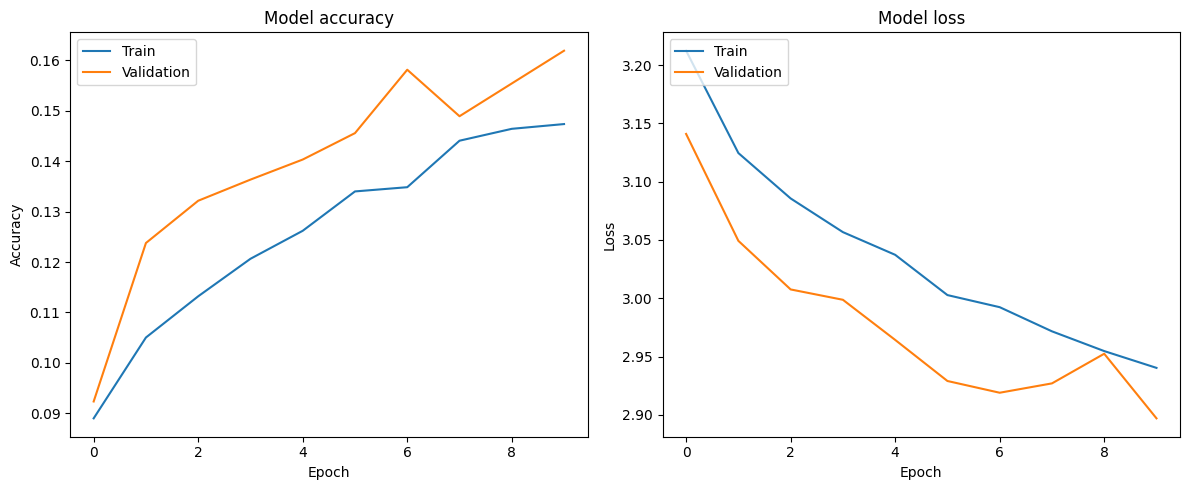

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()